### Notebook Purpose: LightGBM + Baseline Hybrid
- Train a window-based LightGBM hurdle model for 15-minute electricity prices
- Load leakage-safe features and window index (`data/`, `results/window_index/`)
- Fit classifier + regressor and sweep thresholds on validation
- Save checkpoints and inference artifacts to `results/models/`
- Write metrics and plots (active/full sMAPE) to `results/metrics/` and `results/plots/`

### Note
- Shared inputs/outputs and execution conventions are documented in the project README.


In [ ]:
import sys
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Minimal environment setup to keep the notebook focused on the core experiments.
# If you run this elsewhere, update PROJECT_DIR accordingly.
PROJECT_DIR = Path("/content/drive/MyDrive/0.Portfolio/electricity_price_forecasting").resolve()


In [ ]:
project_str = str(PROJECT_DIR)
if project_str not in sys.path:
    sys.path.insert(0, project_str)

DATA_DIR         = PROJECT_DIR / "data"
RESULTS_DIR      = PROJECT_DIR / "results"
METRICS_DIR      = RESULTS_DIR / "metrics"
MODELS_DIR       = RESULTS_DIR / "models"
WINDOW_INDEX_DIR = RESULTS_DIR / "window_index"
LOGS_DIR         = RESULTS_DIR / "logs"
CACHE_DIR        = RESULTS_DIR / "cache"
PLOTS_DIR        = RESULTS_DIR / "plots"

for p in [
    RESULTS_DIR,
    PLOTS_DIR,
    METRICS_DIR,
    MODELS_DIR,
    WINDOW_INDEX_DIR,
    LOGS_DIR,
    CACHE_DIR,
    PLOTS_DIR / "models",
    PLOTS_DIR / "eval/curves",
    PLOTS_DIR / "eval/tables",
    PLOTS_DIR / "eda",
    PLOTS_DIR / "feature_engineering",
]:
    p.mkdir(parents=True, exist_ok=True)


In [62]:
# === Standard imports ===

import os
import sys
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd

import lightgbm as lgb
import pyarrow as pa
import pyarrow.dataset as ds

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("OK: Standard imports ready.")

OK: Standard imports ready.


In [63]:
# === Project paths and imports ===

SRC_DIR = PROJECT_DIR / "src"

TRAIN_PARQUET = DATA_DIR / "TRAIN_Reco_2021_2022_2023_with_time_utc.parquet"
TEST_PARQUET  = DATA_DIR / "TEST_Reco_2024_with_time_utc.parquet"

# Output folders
(RESULTS_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "window_index").mkdir(parents=True, exist_ok=True)

# Ensure src is importable (highest priority)
if str(SRC_DIR) in sys.path:
    sys.path.remove(str(SRC_DIR))
sys.path.insert(0, str(SRC_DIR))

from electricity_forecasting.config import (
    WIN, HORIZON,
    MAX_TEST_WINDOWS, MAX_TRAIN_WINDOWS, MAX_VAL_WINDOWS,
    VALID_RATIO,
    TARGET_COLS, VOLUME_INDEX,
    FREQ, BERLIN_TZ,
)

from electricity_forecasting.preprocessing.features import (
    add_time_features, add_lag_features, add_rolling_features
)

from electricity_forecasting.evaluation.evaluate import (
    save_window_index, load_window_index, hash_window_index,
    evaluate_predictions, active_ratio_from_truth, build_metrics_record,
    save_json, log_run_header
)

from electricity_forecasting.evaluation.reporting import (
    make_metrics_table, save_metrics_table, save_metrics_table_figure
)

from electricity_forecasting.viz.plots import (
    plot_and_save_baseline_vs_model_bar
)

print("OK: Project setup complete.")
print("SRC_DIR exists:", SRC_DIR.exists())
print("TRAIN_PARQUET exists:", TRAIN_PARQUET.exists())
print("TEST_PARQUET exists :", TEST_PARQUET.exists())
print("Constants:", {"WIN": WIN, "HORIZON": HORIZON, "MAX_TEST_WINDOWS": MAX_TEST_WINDOWS, "TARGET_COLS": list(TARGET_COLS), "VOLUME_INDEX": VOLUME_INDEX, "FREQ": FREQ})


OK: Project setup complete.
SRC_DIR exists: True
TRAIN_PARQUET exists: True
TEST_PARQUET exists : True
Constants: {'WIN': 128, 'HORIZON': 10, 'MAX_TEST_WINDOWS': 200000, 'TARGET_COLS': ['high', 'low', 'close', 'volume'], 'VOLUME_INDEX': 3, 'FREQ': '15min'}


In [37]:
# === Utility helpers ===

def nan_stats(name: str, A: np.ndarray, target_cols=None):
    A = np.asarray(A)
    print(f"{name} shape: {A.shape} nan_count: {int(np.isnan(A).sum())}")
    if target_cols is not None and A.ndim == 3:
        for k, col in enumerate(target_cols):
            print(f"  - {col}: nan_count={int(np.isnan(A[..., k]).sum())}")

def assert_no_nan(name: str, A: np.ndarray):
    if np.isnan(A).any():
        nan_stats(name, A, target_cols=list(TARGET_COLS) if A.ndim == 3 else None)
        raise ValueError(f"{name} contains NaNs. Fix data/grid alignment before training.")

def smape_mean(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    num = np.abs(y_pred - y_true) * 2.0
    den = np.abs(y_true) + np.abs(y_pred) + eps
    return float(np.mean(num / den))

print("OK: Utilities ready.")


OK: Utilities ready.


In [64]:
# === ID scan and mapping ===

from electricity_forecasting.io.id_mapping import (
    load_id_mapping_json,
    scan_unique_ids_from_parquet,
    build_id_mapping,
    save_id_mapping_json,
)

ID_MAP_PATH = RESULTS_DIR / "window_index" / "id_code_mapping.json"

t0 = time.time()
if ID_MAP_PATH.exists():
    ID_TO_CODE, CODE_TO_ID, ALL_ID_CODES = load_id_mapping_json(ID_MAP_PATH)
    print("OK: Loaded cached ID mapping | n_ids:", len(ALL_ID_CODES))
else:
    ids_raw = scan_unique_ids_from_parquet(str(TEST_PARQUET), id_col="ID")
    ID_TO_CODE, CODE_TO_ID, ALL_ID_CODES = build_id_mapping(ids_raw)
    save_id_mapping_json(ID_MAP_PATH, id_to_code=ID_TO_CODE, code_to_id=CODE_TO_ID)
    print("OK: Built + saved ID mapping | n_ids:", len(ALL_ID_CODES))

print("Elapsed (ID mapping):", f"{(time.time()-t0):.1f}s")

ALL_IDS_RAW = [str(CODE_TO_ID[i]) for i in ALL_ID_CODES]

# Explicit time bounds (grid definition)
TRAIN_START = pd.Timestamp("2021-01-01 00:00:00", tz="UTC")
TRAIN_END   = pd.Timestamp("2023-12-31 23:45:00", tz="UTC")
TEST_START  = pd.Timestamp("2024-01-01 00:00:00", tz="UTC")
TEST_END    = pd.Timestamp("2024-12-31 23:45:00", tz="UTC")

print("OK: Time bounds fixed.")


OK: Loaded cached ID mapping | n_ids: 672
Elapsed (ID mapping): 0.0s
OK: Time bounds fixed.


In [39]:
# === Window index generation ===

SEED = 42

def steps_in_range(start_utc: pd.Timestamp, end_utc: pd.Timestamp, freq: str = "15min") -> int:
    idx = pd.date_range(start_utc, end_utc, freq=freq, tz="UTC")
    return int(len(idx))

T_train = steps_in_range(TRAIN_START, TRAIN_END, FREQ)
T_test  = steps_in_range(TEST_START,  TEST_END,  FREQ)

n_windows_train_total = T_train - WIN - HORIZON + 1
n_windows_test_total  = T_test  - WIN - HORIZON + 1
assert n_windows_train_total > 0 and n_windows_test_total > 0

cut_pos = int(np.floor(T_train * (1.0 - VALID_RATIO)))
max_start_all   = T_train - WIN - HORIZON
max_start_train = cut_pos - WIN - HORIZON
min_start_val   = cut_pos - WIN

print("Grid sizes:", {"T_train": T_train, "T_test": T_test})
print("Windows per ID:", {"train": n_windows_train_total, "test": n_windows_test_total})
print("Train start_pos range:", (0, max_start_train))
print("Val start_pos range  :", (min_start_val, max_start_all))
print("Test start_pos range :", (0, n_windows_test_total - 1))

def sample_windows_id_balanced_in_range(
    ids: list[int],
    start_min: int,
    start_max: int,
    max_windows: int,
    strategy: str = "spread",
    seed: int = 42,
) -> pd.DataFrame:
    if start_max < start_min:
        raise ValueError("Invalid sampling range: start_max < start_min")

    ids_sorted = sorted(set(map(int, ids)))
    n_ids = len(ids_sorted)

    q = max_windows // n_ids
    r = max_windows % n_ids

    n_range = start_max - start_min + 1
    rng = np.random.default_rng(seed)

    rows = []
    for rank, _id in enumerate(ids_sorted):
        alloc = q + (1 if rank < r else 0)
        alloc = int(min(alloc, n_range))
        if alloc <= 0:
            continue

        if strategy == "spread":
            if alloc == 1:
                picks = np.array([start_min], dtype=np.int64)
            else:
                picks = np.linspace(start_min, start_max, num=alloc, dtype=np.int64)
            picks = np.unique(picks)
            if picks.size < alloc:
                missing = alloc - picks.size
                candidates = np.setdiff1d(np.arange(start_min, start_max + 1, dtype=np.int64), picks, assume_unique=True)
                picks = np.r_[picks, candidates[:missing]]
                picks = np.sort(picks)

        elif strategy == "random":
            pool = np.arange(start_min, start_max + 1, dtype=np.int64)
            if alloc == n_range:
                picks = pool
            else:
                picks = rng.choice(pool, size=alloc, replace=False).astype(np.int64)
                picks = np.sort(picks)
        else:
            raise ValueError("Unknown strategy. Use 'spread' or 'random'.")

        rows.extend((int(_id), int(p)) for p in picks.tolist())

    wi = pd.DataFrame(rows, columns=["ID", "start_pos"]).sort_values(["ID", "start_pos"]).reset_index(drop=True)
    if len(wi) > max_windows:
        wi = wi.iloc[:max_windows].copy()
    return wi

IDS = ALL_ID_CODES

w_tr = sample_windows_id_balanced_in_range(IDS, 0, max_start_train, MAX_TRAIN_WINDOWS, strategy="spread", seed=SEED)
w_va = sample_windows_id_balanced_in_range(IDS, min_start_val, max_start_all, MAX_VAL_WINDOWS, strategy="spread", seed=SEED)
w_te = sample_windows_id_balanced_in_range(IDS, 0, n_windows_test_total - 1, MAX_TEST_WINDOWS, strategy="spread", seed=SEED)

print("Unique IDs train/val/test:", w_tr["ID"].nunique(), w_va["ID"].nunique(), w_te["ID"].nunique())
print("Windows train/val/test:", len(w_tr), len(w_va), len(w_te))

p_tr = RESULTS_DIR / "window_index" / f"train_windows_all_ids_cap{MAX_TRAIN_WINDOWS}.csv"
p_va = RESULTS_DIR / "window_index" / f"val_windows_all_ids_cap{MAX_VAL_WINDOWS}.csv"
p_te = RESULTS_DIR / "window_index" / f"test_windows_all_ids_cap{MAX_TEST_WINDOWS}.csv"

save_window_index(w_tr, p_tr)
save_window_index(w_va, p_va)
save_window_index(w_te, p_te)

print("Saved window indices:")
print("  train:", p_tr.name)
print("  val  :", p_va.name)
print("  test :", p_te.name)

print("Hashes:")
print("  train:", hash_window_index(w_tr))
print("  val  :", hash_window_index(w_va))
print("  test :", hash_window_index(w_te))


Grid sizes: {'T_train': 105120, 'T_test': 35136}
Windows per ID: {'train': 104983, 'test': 34999}
Train start_pos range: (0, 94470)
Val start_pos range  : (94480, 104982)
Test start_pos range : (0, 34998)
Unique IDs train/val/test: 672 672 672
Windows train/val/test: 300000 100000 200000
Saved window indices:
  train: train_windows_all_ids_cap300000.csv
  val  : val_windows_all_ids_cap100000.csv
  test : test_windows_all_ids_cap200000.csv
Hashes:
  train: f68a7c486e7eb04928a78280e905ac1d086315728d1e6cac40816b39b13159c6
  val  : c376472b202091885e46781ed4bcfadf8fcbf1f2f95c1a5c1c89f39e7b2cb7d9
  test : 005f0255eeb9af52c6b63faa2f9cef3d63bc38277714b20e74151379f241a391


In [40]:
# === Per-ID loader and feature builder ===

COLS_OBS = ["ExecutionTime", "ID", "high", "low", "close", "volume"]

def load_one_id_observed(parquet_path: Path, raw_id: str, start_utc: pd.Timestamp, end_utc: pd.Timestamp) -> pd.DataFrame:
    """
    Load one ID from parquet in a RAM-safe way.
    We filter by ID only (robust vs timezone scalar edge cases),
    then filter time range in pandas.
    """
    dataset = ds.dataset(str(parquet_path), format="parquet")
    filt = (ds.field("ID") == pa.scalar(str(raw_id)))
    table = dataset.to_table(columns=COLS_OBS, filter=filt)
    df = table.to_pandas(self_destruct=True)

    df["ExecutionTime"] = pd.to_datetime(df["ExecutionTime"], utc=True, errors="coerce")
    df = df.dropna(subset=["ExecutionTime"])
    df = df[(df["ExecutionTime"] >= start_utc) & (df["ExecutionTime"] <= end_utc)]
    df = df.sort_values("ExecutionTime")
    return df

def build_15min_grid_single_id(
    df_obs: pd.DataFrame,
    raw_id: str,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp,
    freq: str = "15min"
) -> pd.DataFrame:
    """
    Snap timestamps to 15-min grid, deduplicate, then join onto a full grid.
    Prices are forward/back filled; volume missing is filled with 0.
    """
    time_index = pd.date_range(start_utc.floor(freq), end_utc.floor(freq), freq=freq, tz="UTC")

    df = df_obs.copy()
    df["ExecutionTime"] = pd.to_datetime(df["ExecutionTime"], utc=True, errors="coerce")
    df = df.dropna(subset=["ExecutionTime"])

    # Snap to grid for exact join match
    df["ExecutionTime"] = df["ExecutionTime"].dt.floor(freq)

    # Deduplicate timestamps (keep last)
    df = df[["ExecutionTime", "high", "low", "close", "volume"]]
    df = df.sort_values("ExecutionTime").groupby("ExecutionTime", as_index=False).last()

    df = df.set_index("ExecutionTime")
    df_grid = pd.DataFrame(index=time_index).join(df, how="left")

    df_grid["volume"] = df_grid["volume"].fillna(0.0).astype(np.float32)

    for c in ["high", "low", "close"]:
        df_grid[c] = df_grid[c].ffill().bfill()
        df_grid[c] = df_grid[c].fillna(0.0).astype(np.float32)

    df_grid = df_grid.reset_index().rename(columns={"index": "ExecutionTime"})
    df_grid["ID"] = str(raw_id)
    df_grid["pos"] = np.arange(len(df_grid), dtype=np.int32)
    return df_grid

def infer_feature_cols(df_grid: pd.DataFrame) -> list[str]:
    """
    Infer a stable, deterministic feature column list.
    Keeps the notebook robust to naming differences in add_time_features/add_rolling_features.
    """
    cols = list(df_grid.columns)

    feat = []

    # Core volume-derived features
    if "logvol" in cols:
        feat.append("logvol")
    feat += sorted([c for c in cols if c.startswith("logvol_lag")])
    feat += sorted([c for c in cols if c.startswith("logvol_roll")])

    # Current prices as covariates (available at prediction time)
    for c in ["close", "high", "low"]:
        if c in cols and c not in feat:
            feat.append(c)

    # Time features (prefix contains "berlin" by construction)
    feat += sorted([c for c in cols if "berlin" in c.lower()])

    # Remove duplicates while preserving order
    seen = set()
    out = []
    for c in feat:
        if c not in seen:
            out.append(c)
            seen.add(c)

    return out

def build_one_id_grid(
    parquet_path: Path,
    raw_id: str,
    id_code: int,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp
) -> pd.DataFrame:
    df_obs = load_one_id_observed(parquet_path, raw_id, start_utc, end_utc)
    df_grid = build_15min_grid_single_id(df_obs, raw_id, start_utc, end_utc, freq=FREQ)

    # Canonical ID code for modeling
    df_grid["ID"] = int(id_code)

    # Feature engineering
    df_grid["logvol"] = np.log1p(df_grid["volume"].astype(np.float32))

    df_grid = add_time_features(
        df_grid,
        tz=BERLIN_TZ,
        time_col="ExecutionTime",
        prefix="berlin",
        add_cyclical=True,
    )
    df_grid = add_lag_features(df_grid, cols=["logvol"], lags=(1, 2), time_col="ExecutionTime")
    df_grid = add_rolling_features(df_grid, cols=["logvol"], windows=(4, 16), shift=1, time_col="ExecutionTime")

    # Fill NaNs in feature columns only (prices already filled, volume has zeros)
    feat_cols = infer_feature_cols(df_grid)
    for c in feat_cols:
        if c in df_grid.columns:
            df_grid[c] = df_grid[c].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(np.float32)

    return df_grid

# Infer feature columns once using one sample ID (train grid)
SAMPLE_ID_CODE = 0
SAMPLE_RAW_ID  = CODE_TO_ID[SAMPLE_ID_CODE]
df_sample = build_one_id_grid(TRAIN_PARQUET, SAMPLE_RAW_ID, SAMPLE_ID_CODE, TRAIN_START, TRAIN_END)
FEATURE_COLS = infer_feature_cols(df_sample)

print("OK: Grid builder ready.")
print("Feature columns:", FEATURE_COLS)


OK: Grid builder ready.
Feature columns: ['logvol', 'logvol_lag1', 'logvol_lag2', 'logvol_rollmean_16', 'logvol_rollmean_4', 'close', 'high', 'low', 'dow_berlin', 'hour_berlin', 'hour_berlin_cos', 'hour_berlin_sin', 'month_berlin']


In [41]:
# === Window dataset materialization ===

TARGET_COLS_CANON = list(TARGET_COLS)

def extract_windows_for_id(df_grid: pd.DataFrame, w_idx_id: pd.DataFrame):
    """
    For a single ID grid (ID already integer code), extract:
      X_tab:  (N, F) at t_end = start_pos + WIN - 1
      Y_true: (N, H, C) at future steps t_end+1..t_end+H
      Y_base: (N, H, C) persistence baseline from last input (t_end)
    """
    if w_idx_id is None or len(w_idx_id) == 0:
        return None

    start_pos = w_idx_id["start_pos"].to_numpy(dtype=np.int64)
    t_end = start_pos + (WIN - 1)

    feat = df_grid[FEATURE_COLS].to_numpy(dtype=np.float32)      # (T, F)
    tgt  = df_grid[TARGET_COLS_CANON].to_numpy(dtype=np.float32) # (T, C)

    X = feat[t_end, :]  # (N, F)

    steps = t_end[:, None] + np.arange(1, HORIZON + 1, dtype=np.int64)[None, :]
    Y_true = tgt[steps, :]  # (N, H, C)

    last = tgt[t_end, :]  # (N, C)
    Y_base = np.repeat(last[:, None, :], repeats=HORIZON, axis=1)

    y_true_volume = Y_true[:, :, VOLUME_INDEX]  # (N, H)

    return X, Y_true, Y_base, y_true_volume

def build_dataset_from_window_index(
    parquet_path: Path,
    start_utc: pd.Timestamp,
    end_utc: pd.Timestamp,
    window_index: pd.DataFrame,
):
    """
    Build (X, Y_true, Y_baseline, y_true_volume, ids_for_windows) from a canonical window_index.
    Loops over ID codes, maps to raw IDs for parquet filtering.
    """
    X_list, Y_list, Yb_list, yv_list, ids_list = [], [], [], [], []

    for id_code, w_id in window_index.groupby("ID", sort=True):
        id_code = int(id_code)
        raw_id = CODE_TO_ID[id_code]

        df_grid = build_one_id_grid(parquet_path, raw_id=raw_id, id_code=id_code, start_utc=start_utc, end_utc=end_utc)
        out = extract_windows_for_id(df_grid, w_id)
        if out is None:
            continue

        X, Y_true, Y_base, y_true_volume = out

        X_list.append(X)
        Y_list.append(Y_true)
        Yb_list.append(Y_base)
        yv_list.append(y_true_volume)
        ids_list.append(np.full((X.shape[0],), id_code, dtype=np.int64))

    if len(X_list) == 0:
        raise RuntimeError("No windows were materialized. Check window_index and grid building.")

    X_all  = np.concatenate(X_list, axis=0).astype(np.float32)
    Y_all  = np.concatenate(Y_list, axis=0).astype(np.float32)
    Yb_all = np.concatenate(Yb_list, axis=0).astype(np.float32)
    yv_all = np.concatenate(yv_list, axis=0).astype(np.float32)
    ids_all = np.concatenate(ids_list, axis=0).astype(np.int64)

    return X_all, Y_all, Yb_all, yv_all, ids_all

print("OK: Dataset builder ready.")


OK: Dataset builder ready.


In [42]:
# === Materialize splits and sanity checks ===

print("Window index files:")
print("  train:", p_tr.name, "exists:", p_tr.exists())
print("  val  :", p_va.name, "exists:", p_va.exists())
print("  test :", p_te.name, "exists:", p_te.exists())

w_tr = load_window_index(p_tr)
w_va = load_window_index(p_va)
w_te = load_window_index(p_te)

t0 = time.time()
X_tr, Y_tr, Yb_tr, yv_tr, ids_tr = build_dataset_from_window_index(TRAIN_PARQUET, TRAIN_START, TRAIN_END, w_tr)
print("Built train:", X_tr.shape, Y_tr.shape, "Elapsed:", f"{(time.time()-t0)/60:.1f} min")

t0 = time.time()
X_va, Y_va, Yb_va, yv_va, ids_va = build_dataset_from_window_index(TRAIN_PARQUET, TRAIN_START, TRAIN_END, w_va)
print("Built val  :", X_va.shape, Y_va.shape, "Elapsed:", f"{(time.time()-t0)/60:.1f} min")

t0 = time.time()
X_te, Y_te, Yb_te, yv_te, ids_te = build_dataset_from_window_index(TEST_PARQUET, TEST_START, TEST_END, w_te)
print("Built test :", X_te.shape, Y_te.shape, "Elapsed:", f"{(time.time()-t0)/60:.1f} min")

# Basic NaN diagnostics (must be clean)
nan_stats("Y_te", Y_te, target_cols=list(TARGET_COLS))
nan_stats("Yb_te (baseline)", Yb_te, target_cols=list(TARGET_COLS))

assert_no_nan("X_tr", X_tr)
assert_no_nan("X_va", X_va)
assert_no_nan("X_te", X_te)
assert_no_nan("Y_tr", Y_tr)
assert_no_nan("Y_va", Y_va)
assert_no_nan("Y_te", Y_te)
assert_no_nan("Yb_te", Yb_te)

shapes = {
    "X_tr": X_tr.shape, "Y_tr": Y_tr.shape,
    "X_va": X_va.shape, "Y_va": Y_va.shape,
    "X_te": X_te.shape, "Y_te": Y_te.shape,
}
sampling_info = {
    "n_ids_train": int(np.unique(ids_tr).size),
    "n_ids_val": int(np.unique(ids_va).size),
    "n_ids_test": int(np.unique(ids_te).size),
    "n_train_windows_used": int(X_tr.shape[0]),
    "n_val_windows_used": int(X_va.shape[0]),
    "n_test_windows_used": int(X_te.shape[0]),
    "window_index_paths": {"train": p_tr.name, "val": p_va.name, "test": p_te.name},
    "window_index_hashes": {"train": hash_window_index(w_tr), "val": hash_window_index(w_va), "test": hash_window_index(w_te)},
    "test_window_sampling_rule": "ID-balanced + spread start_pos + global cap",
}
constants = {
    "WIN": WIN,
    "HORIZON": HORIZON,
    "MAX_TEST_WINDOWS": MAX_TEST_WINDOWS,
    "MAX_TRAIN_WINDOWS": MAX_TRAIN_WINDOWS,
    "MAX_VAL_WINDOWS": MAX_VAL_WINDOWS,
    "TARGET_COLS": list(TARGET_COLS),
    "VOLUME_INDEX": int(VOLUME_INDEX),
    "FREQ": FREQ,
    "FEATURE_COLS": FEATURE_COLS,
}

log_run_header(model_name="ml_hurdle_lgbm", constants=constants, shapes=shapes, sampling_info=sampling_info)

print("Active ratio on test (truth volume mask):", active_ratio_from_truth(Y_te, volume_index=VOLUME_INDEX))


Window index files:
  train: train_windows_all_ids_cap300000.csv exists: True
  val  : val_windows_all_ids_cap100000.csv exists: True
  test : test_windows_all_ids_cap200000.csv exists: True
Built train: (300000, 13) (300000, 10, 4) Elapsed: 7.2 min
Built val  : (100000, 13) (100000, 10, 4) Elapsed: 7.2 min
Built test : (200000, 13) (200000, 10, 4) Elapsed: 1.8 min
Y_te shape: (200000, 10, 4) nan_count: 0
  - high: nan_count=0
  - low: nan_count=0
  - close: nan_count=0
  - volume: nan_count=0
Yb_te (baseline) shape: (200000, 10, 4) nan_count: 0
  - high: nan_count=0
  - low: nan_count=0
  - close: nan_count=0
  - volume: nan_count=0
=== RUN HEADER ===
Model: ml_hurdle_lgbm
Constants: {'WIN': 128, 'HORIZON': 10, 'MAX_TEST_WINDOWS': 200000, 'MAX_TRAIN_WINDOWS': 300000, 'MAX_VAL_WINDOWS': 100000, 'TARGET_COLS': ['high', 'low', 'close', 'volume'], 'VOLUME_INDEX': 3, 'FREQ': '15min', 'FEATURE_COLS': ['logvol', 'logvol_lag1', 'logvol_lag2', 'logvol_rollmean_16', 'logvol_rollmean_4', 'close'

In [11]:
# === Train LightGBM hurdle model ===

# Targets (volume only)
y_tr_vol = Y_tr[:, :, VOLUME_INDEX]  # (N_tr, H)
y_va_vol = Y_va[:, :, VOLUME_INDEX]  # (N_va, H)
y_te_vol = Y_te[:, :, VOLUME_INDEX]  # (N_te, H)

# Predictions containers
proba_va = np.zeros((X_va.shape[0], HORIZON), dtype=np.float32)
proba_te = np.zeros((X_te.shape[0], HORIZON), dtype=np.float32)

logvol_hat_va = np.zeros((X_va.shape[0], HORIZON), dtype=np.float32)
logvol_hat_te = np.zeros((X_te.shape[0], HORIZON), dtype=np.float32)

# LightGBM params (use sklearn-style names to avoid noisy alias warnings)
LGB_PARAMS_CLS = dict(
    objective="binary",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=200,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
)

LGB_PARAMS_REG = dict(
    objective="regression",
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=100,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
)

for h in range(1, HORIZON + 1):
    ytr = y_tr_vol[:, h - 1]
    yva = y_va_vol[:, h - 1]

    ytr_active = (ytr > 0).astype(np.int32)
    yva_active = (yva > 0).astype(np.int32)

    # 1) Classifier: active vs inactive
    clf = lgb.LGBMClassifier(**LGB_PARAMS_CLS)
    clf.fit(X_tr, ytr_active)

    proba_va[:, h - 1] = clf.predict_proba(X_va)[:, 1].astype(np.float32)
    proba_te[:, h - 1] = clf.predict_proba(X_te)[:, 1].astype(np.float32)

    # 2) Regressor: log1p(volume) on active only
    idx_tr = np.where(ytr_active == 1)[0]
    idx_va = np.where(yva_active == 1)[0]

    if idx_tr.size == 0:
        raise RuntimeError(f"No active samples in train for horizon h={h}. Cannot train regressor.")

    Xtr_reg = X_tr[idx_tr]
    ytr_reg = np.log1p(ytr[idx_tr]).astype(np.float32)

    reg = lgb.LGBMRegressor(**LGB_PARAMS_REG)
    reg.fit(Xtr_reg, ytr_reg)

    # Predict log-vol for all; later apply threshold gate
    logvol_hat_va[:, h - 1] = reg.predict(X_va).astype(np.float32)
    logvol_hat_te[:, h - 1] = reg.predict(X_te).astype(np.float32)

    print(f"OK: h={h} trained. Active rate (train/val): {ytr_active.mean():.4f}/{yva_active.mean():.4f}")

print("OK: All horizons trained.")


[LightGBM] [Info] Number of positive: 19219, number of negative: 280781
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 300000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.064063 -> initscore=-2.681676
[LightGBM] [Info] Start training from score -2.681676


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 19219, number of used features: 13
[LightGBM] [Info] Start training from score 1.346687


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


OK: h=1 trained. Active rate (train/val): 0.0641/0.0620
[LightGBM] [Info] Number of positive: 18942, number of negative: 281058
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 300000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063140 -> initscore=-2.697179
[LightGBM] [Info] Start training from score -2.697179


...

OK: h=9 trained. Active rate (train/val): 0.0664/0.0632
[LightGBM] [Info] Number of positive: 19751, number of negative: 280249
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 300000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.065837 -> initscore=-2.652474
[LightGBM] [Info] Start training from score -2.652474


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000660 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 19751, number of used features: 13
[LightGBM] [Info] Start training from score 1.332140


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


OK: h=10 trained. Active rate (train/val): 0.0658/0.0615
OK: All horizons trained.


Best threshold (selected on validation): 0.65
Best val volume FULL sMAPE: 0.09968621588454411


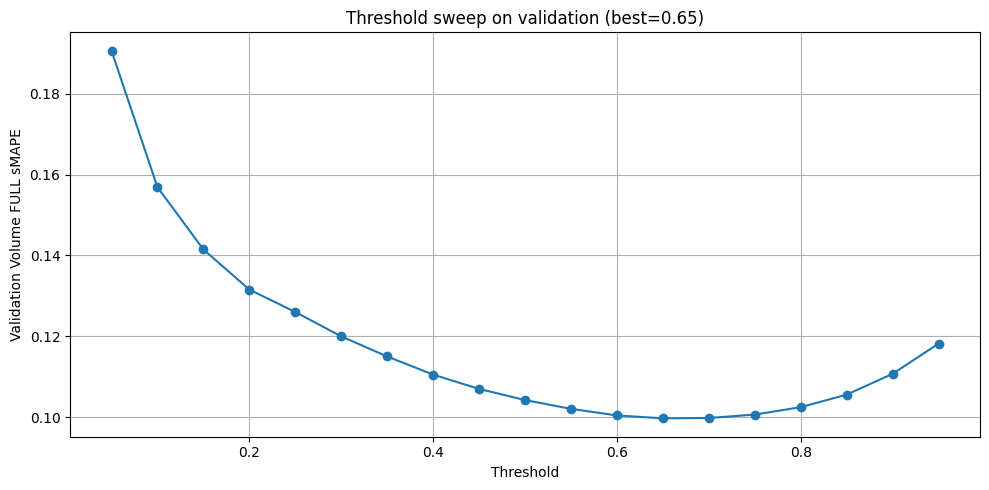

Saved: ml_hurdle_lgbm_threshold_sweep_volume_full.png


In [43]:
# === Threshold sweep and inference ===

def predict_volume_from_hurdle(proba: np.ndarray, logvol_hat: np.ndarray, threshold: float) -> np.ndarray:
    """
    proba/logvol_hat: (N, H)
    returns volume_hat: (N, H) with gate applied
    """
    proba = np.asarray(proba, dtype=np.float64)
    logvol_hat = np.asarray(logvol_hat, dtype=np.float64)

    vol_reg = np.expm1(logvol_hat)
    vol_reg = np.clip(vol_reg, 0.0, None)

    gate = (proba >= float(threshold)).astype(np.float64)
    return (gate * vol_reg).astype(np.float32)

# Sweep thresholds on validation (choose once)
thr_grid = np.linspace(0.05, 0.95, 19)
va_scores = []

y_va_true = y_va_vol.reshape(-1)  # flatten (N*H)

for thr in thr_grid:
    y_va_pred = predict_volume_from_hurdle(proba_va, logvol_hat_va, thr).reshape(-1)
    score = smape_mean(y_va_true, y_va_pred)
    va_scores.append(score)

va_scores = np.array(va_scores, dtype=np.float64)
best_idx = int(np.argmin(va_scores))
best_thr = float(thr_grid[best_idx])
best_score = float(va_scores[best_idx])

print("Best threshold (selected on validation):", best_thr)
print("Best val volume FULL sMAPE:", best_score)

# Plot sweep curve
sweep_df = pd.DataFrame({"threshold": thr_grid, "val_volume_full_smape": va_scores})
curve_path = PLOTS_DIR / "eval/curves" / "ml_hurdle_lgbm_threshold_sweep_volume_full.png"

plt.figure()
plt.plot(sweep_df["threshold"], sweep_df["val_volume_full_smape"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Validation Volume FULL sMAPE")
plt.title(f"Threshold sweep on validation (best={best_thr:.2f})")
plt.tight_layout()
plt.savefig(curve_path, dpi=160)
plt.show()

print("Saved:", curve_path.name)

# Build final TEST volume predictions using best threshold
vol_hat_te = predict_volume_from_hurdle(proba_te, logvol_hat_te, best_thr)  # (N_te, H)

threshold_info = {
    "threshold_grid": [float(x) for x in thr_grid.tolist()],
    "val_volume_full_smape_curve": [float(x) for x in va_scores.tolist()],
    "threshold_selected": float(best_thr),
    "threshold_selected_on": "validation",
    "metric_optimized": "volume_full_smape_on_validation",
}


In [71]:
# === Final evaluation and reporting ===

# Baseline predictions (persistence)
Y_pred_baseline = Yb_te.astype(np.float32)

# Model predictions: keep prices from baseline, replace volume only
Y_pred_model = Yb_te.copy().astype(np.float32)
Y_pred_model[:, :, VOLUME_INDEX] = vol_hat_te.astype(np.float32)

# Canonical metrics (from shared evaluation utility)
baseline_metrics = evaluate_predictions(Y_true=Y_te, Y_pred=Y_pred_baseline, volume_index=VOLUME_INDEX)
model_metrics    = evaluate_predictions(Y_true=Y_te, Y_pred=Y_pred_model,    volume_index=VOLUME_INDEX)

print("Baseline Full/Active:", baseline_metrics)
print("Model    Full/Active:", model_metrics)

# Sanity: metrics must be finite
for k in ["full_smape", "active_smape"]:
    if not np.isfinite(baseline_metrics.get(k, np.nan)):
        raise ValueError(f"Baseline metric {k} is not finite: {baseline_metrics.get(k)}")
    if not np.isfinite(model_metrics.get(k, np.nan)):
        raise ValueError(f"Model metric {k} is not finite: {model_metrics.get(k)}")

# 1) Bar chart (baseline vs model)
metrics_bar = {
    "baseline_full": float(baseline_metrics["full_smape"]),
    "baseline_active": float(baseline_metrics["active_smape"]),
    "model_full": float(model_metrics["full_smape"]),
    "model_active": float(model_metrics["active_smape"]),
}
bar_path = PLOTS_DIR / "models/ml_hurdle_lgbm" / "baseline_vs_model_full_active.png"

plot_and_save_baseline_vs_model_bar(
    metrics_bar=metrics_bar,
    out_png=str(bar_path),
    title="ML Hurdle LGBM vs Baseline (canonical metrics)",
    dpi=160,
)
print("Saved:", bar_path.name)

# 2) Metrics record JSON (standard schema)
run_tag = "ml_hurdle_lgbm_all_ids_window_based"

record = build_metrics_record(
    model_name="ml_hurdle_lgbm",
    run_tag=run_tag,
    constants={
        "WIN": WIN,
        "HORIZON": HORIZON,
        "MAX_TEST_WINDOWS": MAX_TEST_WINDOWS,
        "MAX_TRAIN_WINDOWS": MAX_TRAIN_WINDOWS,
        "MAX_VAL_WINDOWS": MAX_VAL_WINDOWS,
        "TARGET_COLS": list(TARGET_COLS),
        "VOLUME_INDEX": int(VOLUME_INDEX),
        "FREQ": FREQ,
        "FEATURE_COLS": FEATURE_COLS,
    },
    split_info={
        "valid_ratio": float(VALID_RATIO),
        "split_definition": "per-ID time cutoff; train windows end before cutoff; val windows start at/after cutoff",
        "time_bounds": {
            "train_start_utc": str(TRAIN_START),
            "train_end_utc": str(TRAIN_END),
            "test_start_utc": str(TEST_START),
            "test_end_utc": str(TEST_END),
        },
    },
    sampling_info={
        "n_ids_train": int(np.unique(ids_tr).size),
        "n_ids_val": int(np.unique(ids_va).size),
        "n_ids_test": int(np.unique(ids_te).size),
        "n_train_windows_used": int(X_tr.shape[0]),
        "n_val_windows_used": int(X_va.shape[0]),
        "n_test_windows_used": int(X_te.shape[0]),
        "window_index_paths": {"train": str(p_tr), "val": str(p_va), "test": str(p_te)},
        "window_index_hashes": {"train": hash_window_index(w_tr), "val": hash_window_index(w_va), "test": hash_window_index(w_te)},
        "test_window_sampling_rule": "ID-balanced + spread start_pos + global cap",
    },
    baseline_metrics=baseline_metrics,
    model_metrics=model_metrics,
    active_ratio_test=active_ratio_from_truth(Y_te, volume_index=VOLUME_INDEX),
    threshold_info=threshold_info,
    extra={
        "lightgbm_params_classifier": LGB_PARAMS_CLS,
        "lightgbm_params_regressor": LGB_PARAMS_REG,
        "feature_note": "Tabular features taken at window end (t_end); targets are t_end+1..t_end+H.",
    },
)

out_json = RESULTS_DIR / "metrics" / "ml_hurdle_lgbm.json"
save_json(record, out_json)
print("Saved metrics JSON:", out_json.name)

# 3) Metrics table (per-target Full/Active) + save CSV/JSON/PNG
preds = {
    "1. Baseline (Persistence)": Y_pred_baseline,
    "2. ML Hurdle LGBM": Y_pred_model,
}

df_tbl = make_metrics_table(
    Y_true=Y_te,
    preds=preds,
    target_cols=list(TARGET_COLS),
    volume_index=VOLUME_INDEX
    )

display(df_tbl)

tbl_csv = RESULTS_DIR / "metrics" / "metrics_table_ml_hurdle_lgbm_vs_baseline.csv"
tbl_json = RESULTS_DIR / "metrics" / "metrics_table_ml_hurdle_lgbm_vs_baseline.json"
tbl_png = PLOTS_DIR / "eval/tables" / "metrics_table_ml_hurdle_lgbm_vs_baseline.png"

save_metrics_table(df_tbl, tbl_csv, tbl_json)
save_metrics_table_figure(df_tbl, tbl_png, title="ML Hurdle LGBM vs Baseline (Full/Active sMAPE)")

print("Saved:", tbl_csv.name)
print("Saved:", tbl_json.name)
print("Saved:", tbl_png.name)


Baseline Full/Active: {'full_smape': 0.04316420980136336, 'active_smape': 0.5091056927381381}
Model    Full/Active: {'full_smape': 0.039425030706721445, 'active_smape': 0.5288227620760688}
Saved: baseline_vs_model_full_active.png
Saved metrics JSON: ml_hurdle_lgbm.json


,Model,Active High,Active Low,Active Close,Active Volume,Active Total,Full High,Full Low,Full Close,Full Volume,Full Total
0,1. Baseline (Persistence),0.227735,0.23061,0.231246,1.346832,0.509106,0.02761,0.02789,0.027855,0.089302,0.043164
1,2. ML Hurdle LGBM,0.227735,0.23061,0.231246,1.425700,0.528823,0.02761,0.02789,0.027855,0.074345,0.039425


Saved: metrics_table_ml_hurdle_lgbm_vs_baseline.csv
Saved: metrics_table_ml_hurdle_lgbm_vs_baseline.json
Saved: metrics_table_ml_hurdle_lgbm_vs_baseline.png
